# MLP Model

In [3]:
# test out multiple diff layer types, ex. num of hidden layers

import pandas as pd

X_train = pd.read_csv('/content/X_train_scaled.csv')
X_test = pd.read_csv('/content/X_test_scaled.csv')
Y_train = pd.read_csv('/content/Y_train.csv')
Y_test = pd.read_csv('/content/Y_test.csv')

Y_train['Genre'].unique()

array([4, 6, 2, 5, 3, 1, 0])

In [16]:
"we will utilize a FFNN to capture hidden interactions between features."
"fully connected nodes and non-linear activation functions"
"11 X-vars, 1 Y-feature (genre)"
"there are 7 genres"

import keras
from keras.models import Sequential
from keras.layers import Dense
# from keras.optimizers import SGD # stochastic gradient descent

input_dim = 11
hidden_dim_1 = 10
hidden_dim_2 = 10
hidden_dim_3 = 10
output_dim = 7

model = Sequential()

# when i use ReLU instead of sigmoid, i get actual classification
# using sigmoid only makes this model fail, especially in confusion matrix later
model.add(Dense(hidden_dim_1, input_dim=input_dim, activation='relu'))
model.add(Dense(hidden_dim_2, activation='relu'))
model.add(Dense(hidden_dim_3, activation='relu'))
model.add(Dense(output_dim, activation='softmax')) # as per Jake's Piazza instruction

model.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# its own cell because it takes so long to run
fitted_model = model.fit(X_train, Y_train, epochs=50, validation_data=(X_test, Y_test)) #batch_size=128,

Epoch 1/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5354 - val_loss: 1.4302
Epoch 2/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3809 - val_loss: 1.4036
Epoch 3/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3394 - val_loss: 1.3772
Epoch 4/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3234 - val_loss: 1.3671
Epoch 5/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3157 - val_loss: 1.4323
Epoch 6/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3100 - val_loss: 1.3773
Epoch 7/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2994 - val_loss: 1.3388
Epoch 8/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2966 - val_loss: 1.3421
Epoch 9/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2881 - val_loss: 1.3202
Epoch 10/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2828 - val_loss: 1.3437
Epoch 11/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2890 - val_loss: 1.3718
Epoch 12/50
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

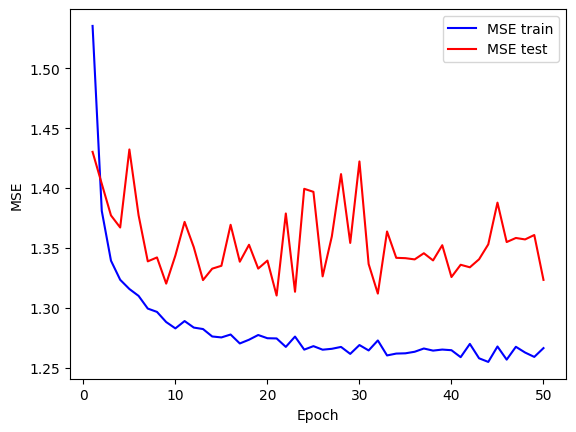

In [18]:
# graph showing reduced mse vs epoch

import matplotlib.pyplot as plt
import numpy as np
epoch = np.arange(1, 51)

train_mse = fitted_model.history['loss']
val_mse = fitted_model.history['val_loss']

plt.plot(epoch, train_mse, 'b-', label='MSE train')
plt.plot(epoch, val_mse, 'r-', label='MSE test')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()


In [22]:
# based on https://www.tensorflow.org/api_docs/python/tf/math/confusion_matrix
import tensorflow as tf
import numpy as np

Y_pred = model.predict(X_test)
labels = np.argmax(Y_test, axis=1)
predictions = np.argmax(Y_pred, axis=1)

confusion_matrix = tf.math.confusion_matrix(
    labels,
    predictions,
    num_classes=7,
    # weights=None,
    # dtype=tf.dtypes.int32,
    # name=None
)

print(confusion_matrix)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
tf.Tensor(
[[216 140 150 280  95 253 250]
 [  0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0]], shape=(7, 7), dtype=int32)


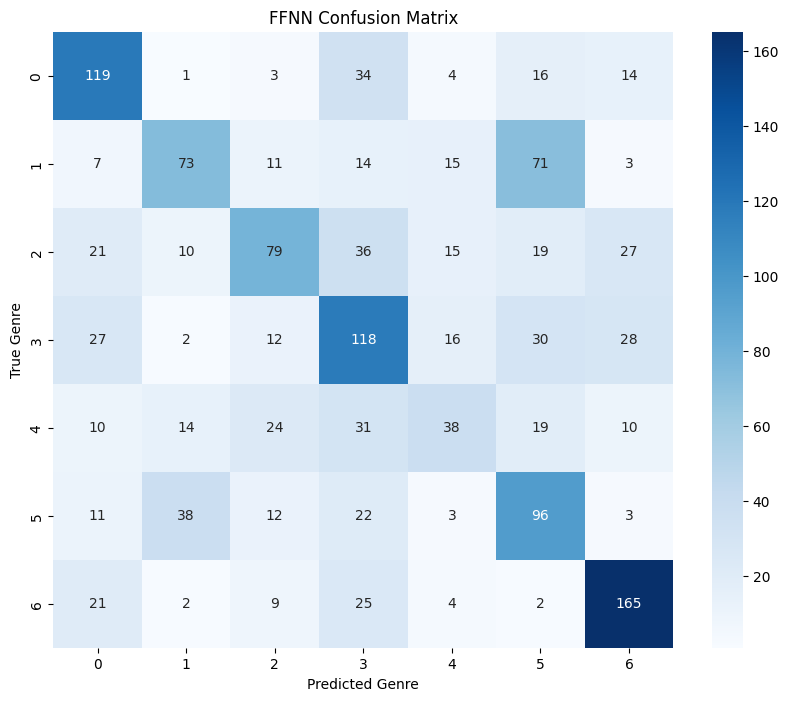

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# accuracy = accuracy_score(Y_test, predictions)
# precision = precision_score(Y_test, predictions, average='macro')
# recall = recall_score(Y_test, predictions, average='macro')
# f1 = f1_score(Y_test, predictions, average='macro')

# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1:", f1)

cm = confusion_matrix(Y_test, predictions)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    # xticklabels=genre_labels,
    # yticklabels=genre_labels
)

plt.title("FFNN Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")

plt.show()